# INFO2950 Final Project Phase 4

Group members: Claire Wang (cw795), Amy Ge (aqg4)

## Introduction

Board games have experienced a major resurgence over the past two decades, which thousands of new titles released each year and millions of players contributing ratings and reviews online. Understanding what makes a board game successful offers valuable insights for both designers and publishers. **Our project will investigate the key factors that predict a game's overall ranking on BoardGameGeek,** the world's largest board game database. Using a comprehensive dataset we found from Kaggle that includes game attributes, community feedback metrics, and contributor information, our study aims to identify which elements most strongly influence a game's position in the BBG rankings through single and multi-variable regression. By modeling these relationships, **we hope to uncover the design and market characteristics most associated with board game success.**

## Research Question

***What factors (eg. category, designer, complexity, play time, etc.), or combination of factors, best predict a game's overall BBG ranking?***

## Data Description

https://www.kaggle.com/datasets/chik0di/board-games-dataset-complete-features

The dataset we are using comes from Kaggle, and offers an extensive comilation of board game metadata drawn from the BoardGameGeek (BBG) community alongside pricing information from Amazon. It encompasses over 17,000 titles and provides detailed attributes including publication year, recommended age and player counts, average play time, complexity scores ("weight"), user review counts, ownership and wishlist statistics, category and mechanic classifications, designer and publisher credits, rating distributions from 1-10, and curent Amazon price listings.

This dataset was created and updated by **Chikodi Obu,** a **Kaggle dataset expert,** who is also a professional **Data and Analytics lead, Data Engineer**, as well as a **SQL instructor** (https://www.linkedin.com/in/chikodi-obu-278b5b264/). There is no information on Kaggle as to why the dataset is created or its funding. According to Kaggle, this dataset is updated weekly, and for our project we will be using the version taken from Kaggle on **11/20/2025.**


# Data Cleaning

As an *initial* data-clean, we removed duplicate game titles and dropped rows missing key fields (avg_rating, num_ratings, release_year). We kept games released between 1900 and 2025 (resulting dataset spans 1925–2025) and only those with a positive number of ratings. For quick exploration, we added three helper variables: players_mid (mean of min_players and max_players), playtime_mid (mean of min_playtime and max_playtime), and log_num_ratings (log transform to reduce skew). The cleaned dataset contains 1,975 rows and 60 columns and is saved as bgg_clean.csv.

### Load raw dataset
Load the Kaggle dataset to preview its shape and structure before cleaning.

In [52]:
# LOAD RAW DATA
# Import pandas and numpy, then load the dataset from local path.
import pandas as pd
import numpy as np

CSV_PATH = "/content/boardgame-geek-dataset_organized.csv"  # local raw, not in repo
df = pd.read_csv(CSV_PATH)

# Print shape and show first few rows.
print("raw shape:", df.shape)
display(df.head(3))

raw shape: (2000, 57)


,row_id,boardgame,release_year,min_players,max_players,min_playtime,max_playtime,minimum_age,avg_rating,num_ratings,...,rank_strategy,rank_thematic,rank_family,rank_war,rank_customizable,rank_abstract,rank_party,rank_childrens,url,description
0,1,Brass: Birmingham,2018,2,4,60,120,14,8.575,53548,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://boardgamegeek.com/boardgame/224517/bra...,"Build networks, grow industries, and navigate ..."
1,2,Pandemic Legacy: Season 1,2015,2,4,60,60,13,8.512,56071,...,3.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,https://boardgamegeek.com/boardgame/161936/pan...,Mutating diseases are spreading around the wor...
2,3,Ark Nova,2021,1,4,90,150,14,8.539,54528,...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://boardgamegeek.com/boardgame/342942/ark...,"Plan and build a modern, scientifically manage..."


### Remove duplicates and drop missing values
Eliminate duplicate titles and drop rows missing critical variables.

In [53]:
# REMOVE DUPLICATES AND DROP NA
# Drop duplicate rows based on boardgame title.
df = df.drop_duplicates(subset=["boardgame"])

# Drop rows with missing core fields.
df = df.dropna(subset=["avg_rating", "num_ratings", "release_year"])

print("after filters:", df.shape)

after filters: (1985, 57)


### Keep valid release years and positive rating counts
Restrict games to the reasonable year range and ensure positive review counts.

In [54]:
# FILTER VALID YEARS AND RATINGS
df = df[df["release_year"].between(1900, 2025)]
df = df[pd.to_numeric(df["num_ratings"], errors="coerce") > 0]
print("after year and rating filters:", df.shape)

after year and rating filters: (1975, 57)


### Create helper variables
Compute midpoint player count, midpoint play time, and log transformed review counts.

In [55]:
# FEATURE ENGINEERING
df["players_mid"] = (pd.to_numeric(df["min_players"], errors="coerce") +
                     pd.to_numeric(df["max_players"], errors="coerce")) / 2

df["playtime_mid"] = (pd.to_numeric(df["min_playtime"], errors="coerce") +
                      pd.to_numeric(df["max_playtime"], errors="coerce")) / 2

df["log_num_ratings"] = np.log1p(pd.to_numeric(df["num_ratings"], errors="coerce"))

print("new columns added:", [c for c in ["players_mid","playtime_mid","log_num_ratings"] if c in df.columns])
display(df.head(3))

new columns added: ['players_mid', 'playtime_mid', 'log_num_ratings']


,row_id,boardgame,release_year,min_players,max_players,min_playtime,max_playtime,minimum_age,avg_rating,num_ratings,...,rank_war,rank_customizable,rank_abstract,rank_party,rank_childrens,url,description,players_mid,playtime_mid,log_num_ratings
0,1,Brass: Birmingham,2018,2,4,60,120,14,8.575,53548,...,NaN,NaN,NaN,NaN,NaN,https://boardgamegeek.com/boardgame/224517/bra...,"Build networks, grow industries, and navigate ...",3.0,90.0,10.888352
1,2,Pandemic Legacy: Season 1,2015,2,4,60,60,13,8.512,56071,...,NaN,NaN,NaN,NaN,NaN,https://boardgamegeek.com/boardgame/161936/pan...,Mutating diseases are spreading around the wor...,3.0,60.0,10.934392
2,3,Ark Nova,2021,1,4,90,150,14,8.539,54528,...,NaN,NaN,NaN,NaN,NaN,https://boardgamegeek.com/boardgame/342942/ark...,"Plan and build a modern, scientifically manage...",2.5,120.0,10.906488


### Save cleaned dataset
Save the processed data as bgg_clean.csv for later analysis and EDA.

In [56]:
# SAVE CLEANED DATASET
OUT_PATH = "/content/bgg_clean.csv"
df.to_csv(OUT_PATH, index=False)
print("saved cleaned dataset to:", OUT_PATH)
print("cleaned shape:", df.shape)

saved cleaned dataset to: /content/bgg_clean.csv
cleaned shape: (1975, 60)


### Verify cleaning results
Confirm that duplicates and invalid records are removed.


In [57]:
# VALIDATION
print("Duplicate boardgame titles:", df.duplicated(subset=["boardgame"]).sum())
print("Year range:", df["release_year"].min(), "-", df["release_year"].max())
print("Nonpositive num_ratings:", (pd.to_numeric(df["num_ratings"], errors="coerce") <= 0).sum())

Duplicate boardgame titles: 0
Year range: 1925 - 2025
Nonpositive num_ratings: 0


#Data Limitations
While the BoardGameGeek dataset provides comprehensive coverage of thousands of board games with detailed statistics on ratings, complexity, and ownership, it still contains several limitations that may influence the interpretation of our analyses. These limitations mainly stem from how the data was collected (via web scraping) and the nature of the BGG community itself. Understanding these gaps is important for accurately framing the scope and generalizability of our results.


###Sampling Bias / User Representation
 The dataset is sourced from the BoardGameGeek (BGG) community, which mainly consists of hobbyist and experienced players. It seems their preferences tend to favor more complex, strategic, or Euro-style games over casual or family-oriented ones.
Analyses involving ratings or popularity metrics are likely to reflect the preferences of an enthusiast subcommunity rather than the general market. As a result, **highly rated games in this dataset may not be representative of mainstream appeal.**


###Data Reduction from Cleaning and Missingness
Several fields in the original dataset, such as minimum age, Amazon price, and designer information, contained missing or placeholder values. During preprocessing, we removed incomplete rows and excluded variables with excessive missingness to ensure data quality.  While the final dataset is now complete for analysis, this cleaning process reduced the number of usable records. Consequently, our results are based on a filtered subset of the original data that may **overrepresent well-documented or commercially available games.** This limits the generalizability of our conclusions to the broader set of games listed on BoardGameGeek.


###Temporal Inconsistency
 Ratings, ownership counts, and prices were scraped at different times, but the dataset does not include clear timestamps for when each metric was recorded. This inconsistency limits any **longitudinal or trend-based interpretations.** For example, we cannot tell whether changes in ratings reflect genuine shifts in popularity or simply the timing of data collection.


###Scraping and Data Quality Errors
 Because the dataset was gathered through automated web scraping, some entries may contain parsing errors or outdated information due to changes in the BGG website structure. These inconsistencies can slightly **distort descriptive statistics** like mean ratings or ranking distributions and may introduce **noise** into predictive analyses.


###Duplicate or Merged Game Entries
 BGG includes multiple editions and expansions of the same game under similar names, and it’s likely not all duplicates were merged during dataset preparation. Duplicate listings can inflate popularity or ownership counts, making certain titles appear **more significant in correlation or ranking analyses** than they actually are.


# Exploratory Data Analysis
For our initial Exploratory Data Analysis (EDA), we reported several important summary statistics and plotted bivariate scatterplots visualizing the relationship between variables of interest that may yield meaningful information related to our research question. In addition, we also fitted some simple linear regression models also investigating bivariate relationships that we infer may have an influence in determining board game success and ranking according to BGG metrics.

**Import any necessary libraries for code execution**

In [58]:
# Import necessary libraries
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

from scipy import stats
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm

import seaborn as sns
import matplotlib.pyplot as plt


**Create cleaned and modified DataFrame**  
This DataFrame will be used for data analysis of modern (1990-2025) board games to draw conclusions about variable relationships and observe trends in board game characteristics over time.

In [59]:
# Store modified dataframe in new variable with selective cleaning
df = pd.read_csv('boardgame-geek-dataset_organized.csv')
df = df[df['release_year'] >= 1990]
df['amazon_price'] = df['amazon_price'].dropna()
df['game_age'] = 2025-df['release_year']
df['playtime_mid'] = (df['min_playtime'] + df['max_playtime']) / 2
df = df[df['playtime_mid'] > 0]
df['log_playtime_mid'] = np.log1p(df['playtime_mid'])
df['log_num_ratings'] = np.log1p(df['num_ratings'])

**Compute and print relevant summary statistics across our DataFrame that may be useful**  
We will use these values as a starting point of our exploratory data analysis. From these statistics, we will formulate conclusions and real-world interpretations based on the comparison of our analysis of other BGG popularity metrics to these overall values as reference.

In [60]:
# Calculate and print mean values for variables of interest
meanRate = df['avg_rating'].mean()
print(f"Mean Avg Rating: {np.round(meanRate, 2)}")
meanComp = df['complexity'].mean()
print(f"Mean Complexity: {np.round(meanComp, 2)}")
meanPrice = df['amazon_price'].mean()
print(f"Mean Price (in USD): {np.round(meanPrice, 2)}")
meanTotPlays = df['total_plays'].mean()
print(f"Mean Total Plays: {np.round(meanTotPlays, 2)}")
meanFans = df['fans'].mean()
print(f"Mean Fans: {np.round(meanFans, 2)}")
meanPageView = df['page_views'].mean()
print(f"Mean Page Views: {np.round(meanPageView, 2)}")
meanStdDev = df['std_deviation'].mean()
print(f"Mean Std Dev of Ratings: {np.round(meanStdDev, 2)}")

Mean Avg Rating: 7.43
Mean Complexity: 2.53
Mean Price (in USD): 59.72
Mean Total Plays: 40911.8
Mean Fans: 705.28
Mean Page Views: 845731.56
Mean Std Dev of Ratings: 1.33


**Plot scatterplots to describe bivariate relationships between key ranking variables**  
We plotted the graphs of several combinations of input and output variables in order to visually approximate whether or not there is a correlational relationship between a variable pair and roughly how strong that relationship may be. These graphs also give us information on data that may need to be transformed for future linear or logistic regression models.

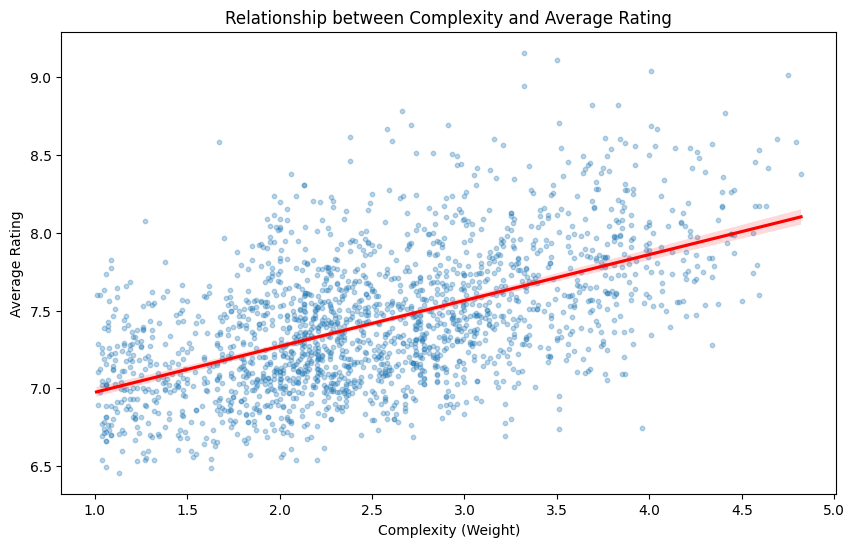

In [61]:
plt.figure(figsize=(10, 6))
sns.regplot(x ='complexity', y='avg_rating', data = df,
            scatter_kws={'alpha':0.3, 's':10} , line_kws={'color':'red'})
plt.title('Relationship between Complexity and Average Rating')
plt.xlabel('Complexity (Weight)')
plt.ylabel('Average Rating')
plt.show()

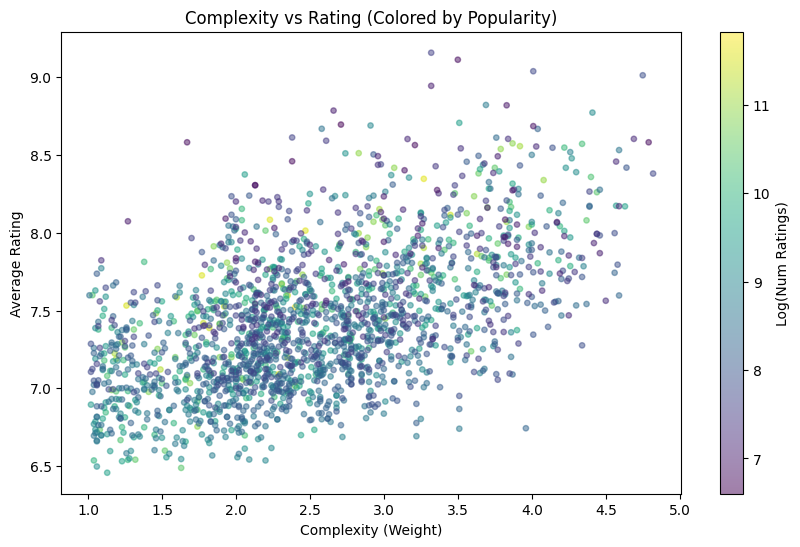

In [62]:
plt.figure(figsize = (10, 6))
scatter = plt.scatter(df['complexity'], df['avg_rating'],
                      c=df['log_num_ratings'], cmap='viridis', alpha=0.5, s=15)
plt.colorbar(scatter, label= 'Log(Num Ratings)')
plt.title('Complexity vs Rating (Colored by Popularity)')
plt.xlabel('Complexity (Weight)')
plt.ylabel('Average Rating')
plt.show()

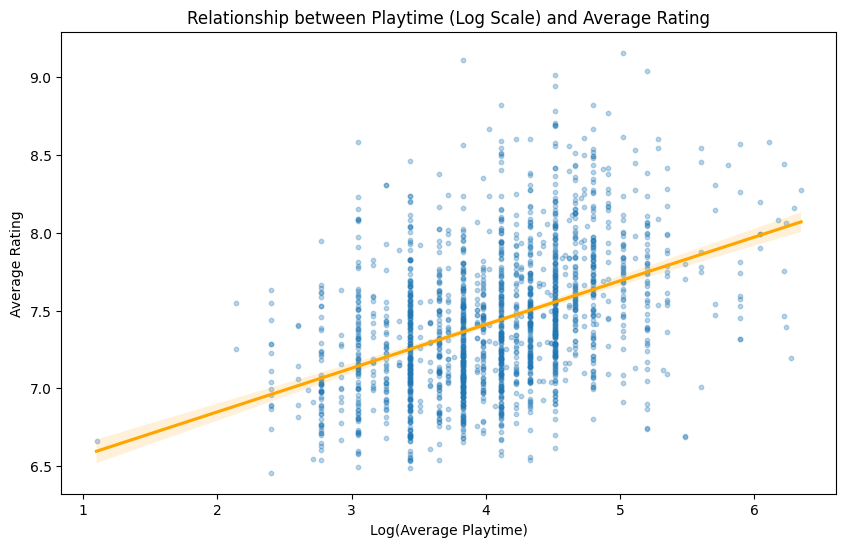

In [63]:
plt.figure(figsize=(10, 6))
sns.regplot(x='log_playtime_mid', y = 'avg_rating', data=df,
            scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'orange'})
plt.title('Relationship between Playtime (Log Scale) and Average Rating')
plt.xlabel('Log(Average Playtime)')
plt.ylabel('Average Rating')
plt.show()

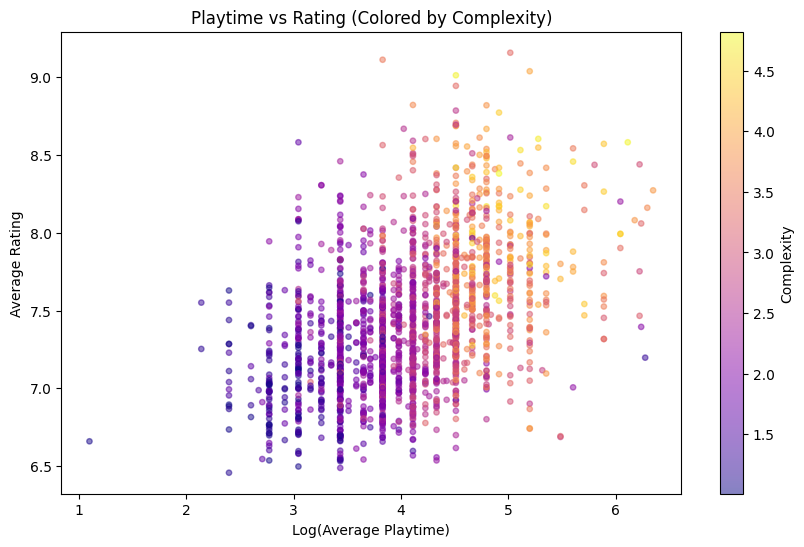

In [64]:
plt.figure(figsize =(10, 6))
scatter2 = plt.scatter(df['log_playtime_mid'], df['avg_rating'],
                       c=df['complexity'], cmap='plasma', alpha=0.5, s=15)
plt.colorbar(scatter2, label='Complexity')
plt.title('Playtime vs Rating (Colored by Complexity)')
plt.xlabel('Log(Average Playtime)')
plt.ylabel('Average Rating')
plt.show()

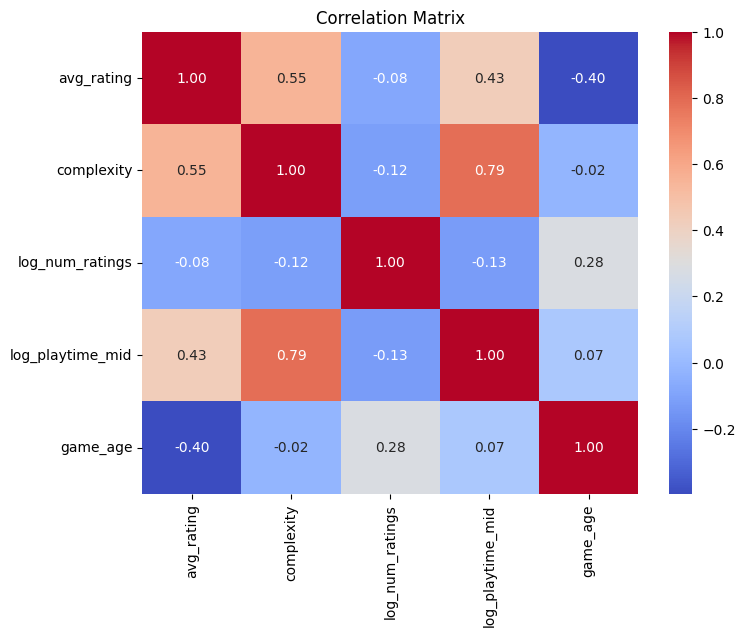

In [65]:
plt.figure(figsize=(8, 6))
corr_cols =['avg_rating', 'complexity', 'log_num_ratings', 'log_playtime_mid', 'game_age']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

/tmp/ipython-input-3253924424.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='min_players', y='avg_rating', data=common_players, palette = 'Pastel1')


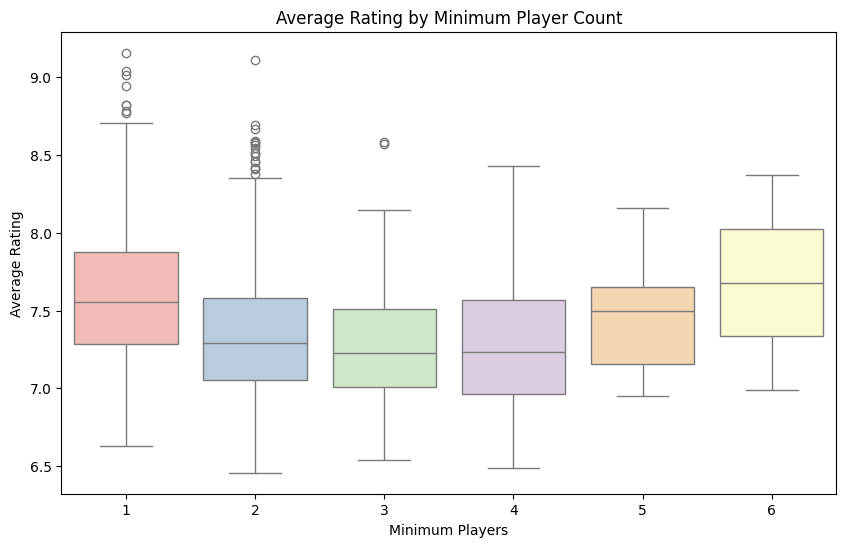

In [66]:
plt.figure(figsize=(10, 6))
common_players = df[df['min_players'].isin([1, 2, 3, 4, 5, 6])]
sns.boxplot(x='min_players', y='avg_rating', data=common_players, palette = 'Pastel1')
plt.title('Average Rating by Minimum Player Count')
plt.xlabel('Minimum Players')
plt.ylabel('Average Rating' )
plt.show()

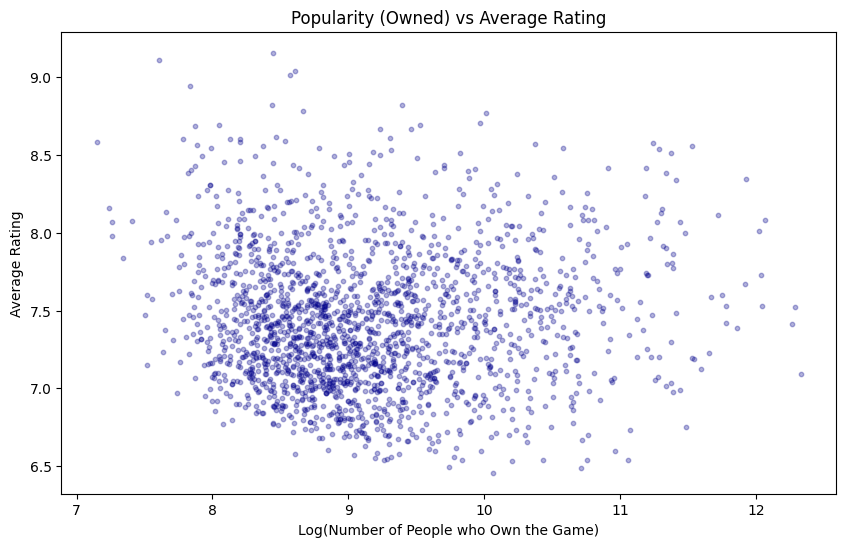

In [67]:
plt.figure(figsize=(10, 6))
plt.scatter(np.log1p(df['owned']),df['avg_rating'], alpha=0.3, color='darkblue', s=10)
plt.title('Popularity (Owned) vs Average Rating')
plt.xlabel('Log(Number of People who Own the Game)')
plt.ylabel('Average Rating')
plt.show()

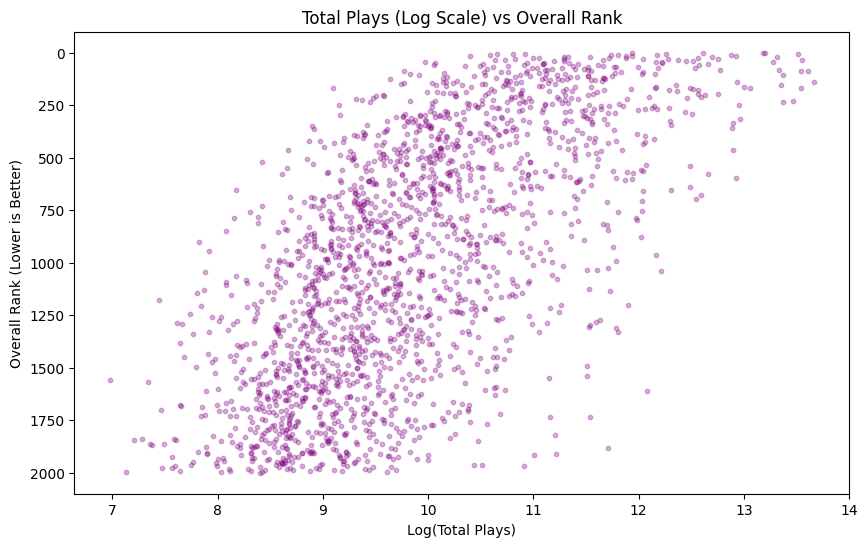

In [68]:
plt.figure(figsize=(10, 6))
plt.scatter(np.log1p(df['total_plays']), df['rank_overall'], alpha=0.3, color='purple', s=10)
plt.title('Total Plays (Log Scale) vs Overall Rank')
plt.xlabel('Log(Total Plays)')
plt.ylabel('Overall Rank (Lower is Better)')
plt.gca().invert_yaxis()
plt.show()

**Perform linear regression on suspected correlationally-related variable pairs**  
After assessing the selection of scatterplot graphs, our group chose three variable pairs to do linear regression fits on. Our variables of interest generally have continuous, non-binary values so we used linear regression instead of logistic regression to create our models. We then interpreted our results, combining context and domain expertise to infer the significance of these values.

We suspect complexity (weight) is linearly correlated with average rating, so we will perform a linear regression to confirm.

Selected Variables: complexity (Independent) vs avg_rating (Dependent)
Correlation Coefficient: 0.5497
R-squared: 0.3021
Regression Equation: y = 0.2955x + 6.6781


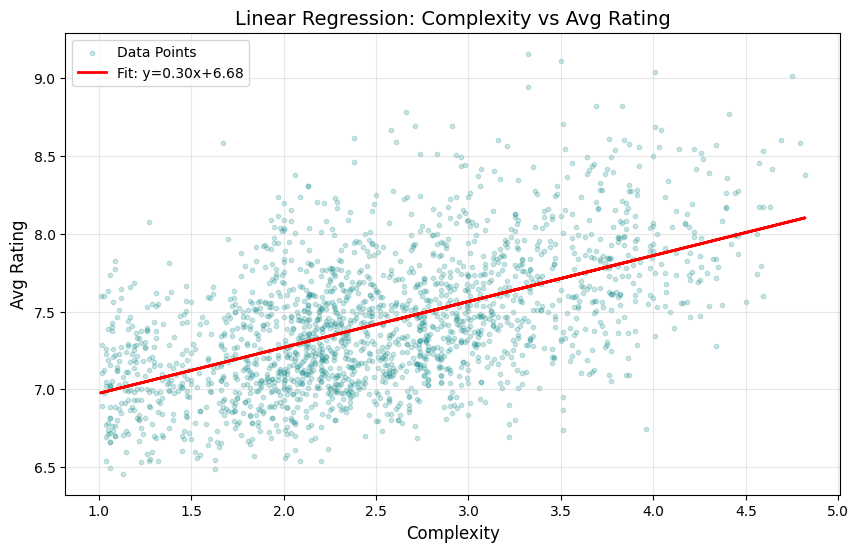

In [69]:
var_x = 'complexity'
var_y = 'avg_rating'

df_reg = df[[var_x, var_y]].dropna()

X = df_reg[[var_x]].values
y = df_reg[var_y].values

reg = LinearRegression()
reg.fit(X, y)
y_pred = reg.predict(X)

slope = reg.coef_[0]
intercept= reg.intercept_
r_squared= r2_score(y, y_pred)
correlation= df_reg[var_x].corr(df_reg[var_y])

print(f"Selected Variables: {var_x} (Independent) vs {var_y} (Dependent)")
print(f"Correlation Coefficient: {correlation:.4f}")
print(f"R-squared: {r_squared:.4f}")
print(f"Regression Equation: y = {slope:.4f}x + {intercept:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(df_reg[var_x], df_reg[var_y], alpha=0.2, s=10, color='teal', label='Data Points')
plt.plot(df_reg[var_x], y_pred, color='red', linewidth=2, label=f'Fit: y={slope:.2f}x+{intercept:.2f}')

plt.title(f'Linear Regression: {var_x.capitalize()} vs {var_y.replace("_", " ").title()}', fontsize=14)
plt.xlabel(var_x.capitalize(), fontsize=12)
plt.ylabel(var_y.replace("_", " ").title(), fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('linear_regression_plot.png')
plt.show()

We can see from the graph above that there is a slightly positive linear correlation between the two variables. The slope of the line of best fit (0.3) tells us approximately 30% of the variance we see in the rating can be explained by the complexity of the game.

We also suspect there is linear correlation between release year and average rating. Lets perform another linear regression to confirm this hypothesis:

Variables: release_year vs avg_rating
Correlation: 0.3967
R-squared: 0.1573
Equation: y = 0.0256x + -44.2499


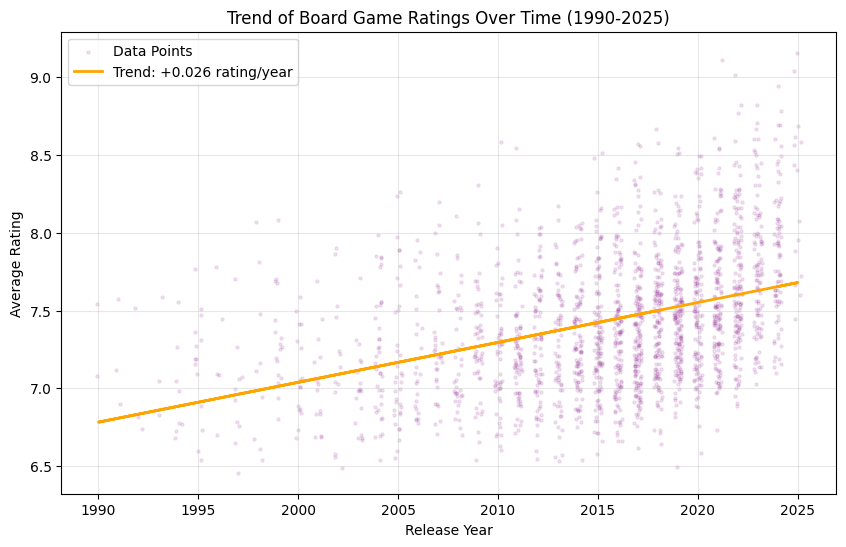

In [70]:
var_x = 'release_year'
var_y = 'avg_rating'

df_reg= df[[var_x, var_y]].dropna()
X = df_reg[[var_x]].values
y = df_reg[var_y].values

reg = LinearRegression()
reg.fit(X, y)
y_pred = reg.predict(X)

slope = reg.coef_[0]
intercept = reg.intercept_
r_squared = r2_score(y, y_pred)
correlation = df_reg[var_x].corr(df_reg[var_y])

print(f"Variables: {var_x} vs {var_y}")
print(f"Correlation: {correlation:.4f}")
print(f"R-squared: {r_squared:.4f}")
print(f"Equation: y = {slope:.4f}x + {intercept:.4f}")

plt.figure(figsize=(10, 6))
x_jittered = df_reg[var_x] + np.random.uniform(-0.2, 0.2, size=len(df_reg))
plt.scatter(x_jittered, df_reg[var_y], alpha=0.1, s=5, color='purple', label='Data Points')
plt.plot(df_reg[var_x], y_pred, color = 'orange', linewidth=2, label=f'Trend: +{slope:.3f} rating/year')

plt.title('Trend of Board Game Ratings Over Time (1990-2025)')
plt.xlabel('Release Year')
plt.ylabel('Average Rating')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('year_vs_rating_regression.png')
plt.show()

As we can see from the graph above, release year and average rating are indeed linearly correlated. The trend is noticably positive, and the slope of our line of best fit tells us that on average, board game ratings increase approximately 0.026 points per year.

#Preregistration Statement 1
##Hypothesis 1:
Games with higher complexity (on the weight scale from 1 to 5) tend to have higher average ratings, even after accounting for the number of ratings they receive.

##Proposed Analysis:
We will run a multiple linear regression using avg_rating as the dependent variable and both weight (complexity score) and log_num_ratings (log-transformed number of user ratings) as independent variables. Before running the regression, we will also compute Pearson and Spearman correlations between avg_rating and weight and visualize them with a scatterplot to check for linear versus monotonic relationships.
This approach will allow us to test whether complexity predicts a game's average rating while controlling for its popularity.

Pearson Correlation (Complexity vs Avg Rating): 0.5497
Spearman Correlation (Complexity vs Avg Rating): 0.5316


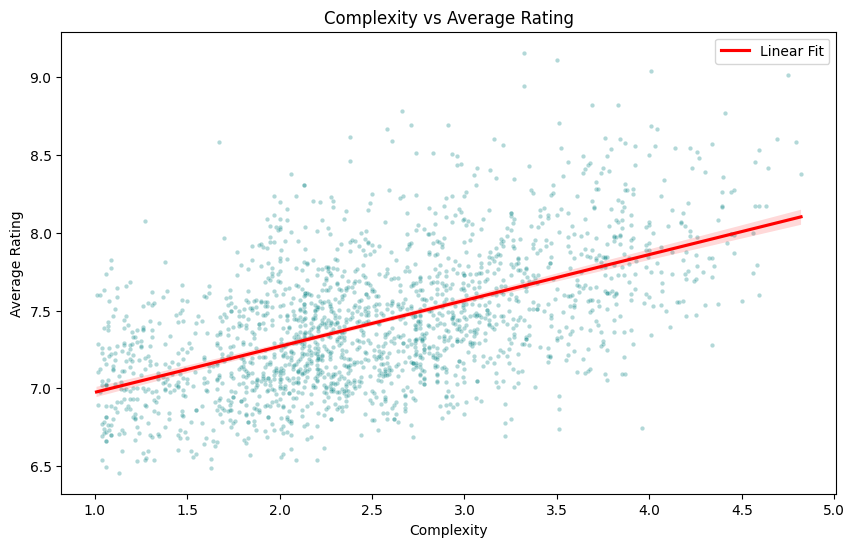

                            OLS Regression Results                            
Dep. Variable:             avg_rating   R-squared:                       0.302
Model:                            OLS   Adj. R-squared:                  0.302
Method:                 Least Squares   F-statistic:                     422.3
Date:                Fri, 21 Nov 2025   Prob (F-statistic):          4.52e-153
Time:                        03:33:25   Log-Likelihood:                -808.24
No. Observations:                1951   AIC:                             1622.
Df Residuals:                    1948   BIC:                             1639.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               6.7493      0.084     

In [71]:
pearson_corr, p_p = pearsonr(df['complexity'], df['avg_rating'])
spearman_corr, s_p = spearmanr(df['complexity'], df['avg_rating'])

print(f"Pearson Correlation (Complexity vs Avg Rating): {pearson_corr:.4f}")
print(f"Spearman Correlation (Complexity vs Avg Rating): {spearman_corr:.4f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(x='complexity', y='avg_rating', data=df, alpha=0.3, s=10, color='teal')
sns.regplot(x='complexity', y='avg_rating', data=df, scatter=False, color='red', label='Linear Fit')
plt.title('Complexity vs Average Rating')
plt.xlabel('Complexity')
plt.ylabel('Average Rating')
plt.legend()
plt.savefig('complexity_vs_rating_analysis.png')
plt.show()

X = df[['complexity', 'log_num_ratings']]
y = df['avg_rating']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

###Analysis for Hypothesis 1:
We have found the Pearson Correlation is 0.5497 and the Spearman Correlation is 0.5316. Since both of these values represent a strong positive correlation, therefore we can conclude that as game complexity increases, the average rating also tends to increase. The coef value of complexity tells us for every one point increase in complexity, the average rating increase by approximately 0.29 points, and the p value (which is less than 0.001) suggests that this is statistically significant.

#Preregistration Statement 2
##Hypothesis 2:
Games with longer average playtimes receive lower average ratings, controlling for complexity.

##Proposed Analysis:
We will run another multiple linear regression using avg_rating as the dependent variable and playtime_mid (average of min_playtime and max_playtime) and weight (complexity score) as independent variables. This will test whether longer games tend to have lower ratings once complexity is accounted for.
Because playtime_mid is likely skewed, we will also test a log-transformed version (log_playtime_mid) to see if it improves model fit and reduces heteroskedasticity, as discussed in class.


--- Model 1 Summary (Linear Playtime) ---
                            OLS Regression Results                            
Dep. Variable:             avg_rating   R-squared:                       0.304
Model:                            OLS   Adj. R-squared:                  0.303
Method:                 Least Squares   F-statistic:                     425.0
Date:                Fri, 21 Nov 2025   Prob (F-statistic):          6.78e-154
Time:                        03:33:25   Log-Likelihood:                -806.34
No. Observations:                1951   AIC:                             1619.
Df Residuals:                    1948   BIC:                             1635.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const 

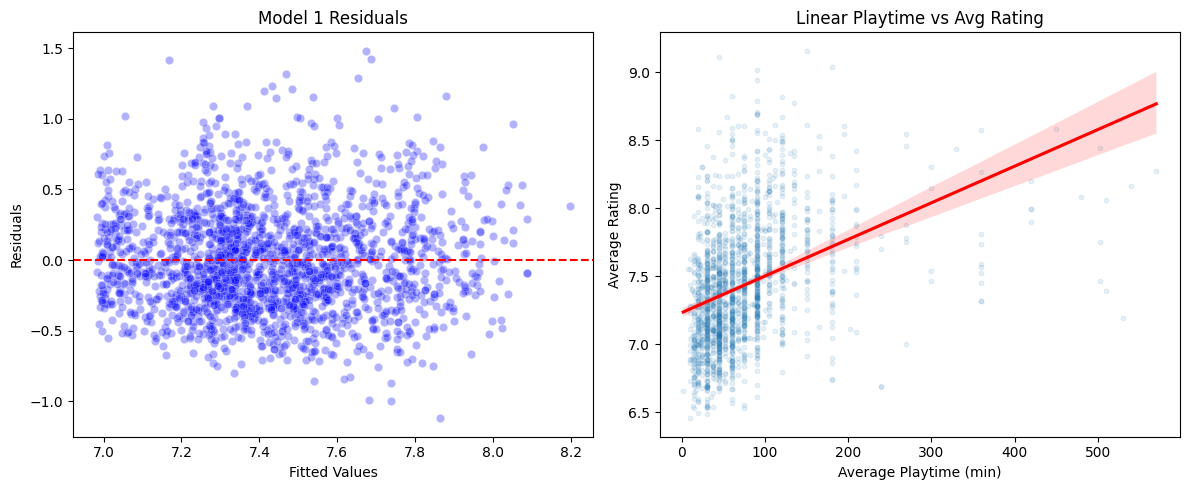

In [72]:
X1 = df[['complexity', 'playtime_mid']]
X1 = sm.add_constant(X1)
y = df['avg_rating']
model1 = sm.OLS(y, X1).fit()

print("--- Model 1 Summary (Linear Playtime) ---")
print(model1.summary())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x = model1.fittedvalues, y= model1.resid, alpha=0.3, color='blue')
plt.axhline(0, color='red', linestyle='--')
plt.title('Model 1 Residuals')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')

plt.subplot(1, 2, 2)
sns.regplot(x='playtime_mid', y='avg_rating', data=df,
            scatter_kws={'alpha':0.1, 's':10}, line_kws={'color':'red'})
plt.title('Linear Playtime vs Avg Rating')
plt.xlabel('Average Playtime (min)')
plt.ylabel('Average Rating')

plt.tight_layout()
plt.savefig('model1_analysis.png')
plt.show()

After modeling the relationship between avg_rating and playtime_mid, we see that the coefficient for playtime is basically zero and not significant enough to draw a conclusion. Now lets try modeling with log_playtime_mid instead:

--- Model 2 Summary (Log-Transformed Playtime) ---
                            OLS Regression Results                            
Dep. Variable:             avg_rating   R-squared:                       0.302
Model:                            OLS   Adj. R-squared:                  0.301
Method:                 Least Squares   F-statistic:                     421.7
Date:                Fri, 21 Nov 2025   Prob (F-statistic):          6.62e-153
Time:                        03:33:26   Log-Likelihood:                -808.62
No. Observations:                1951   AIC:                             1623.
Df Residuals:                    1948   BIC:                             1640.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

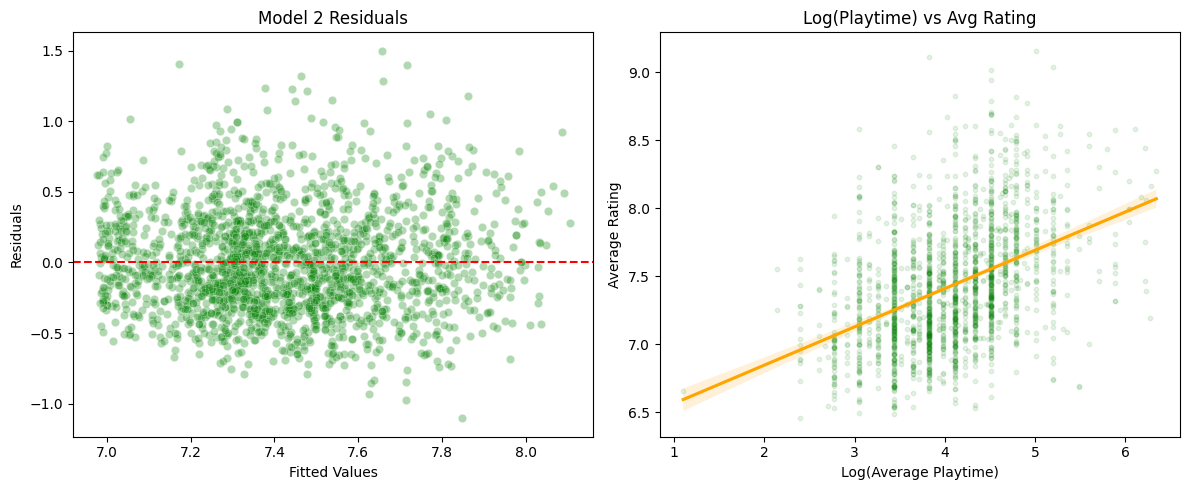

In [73]:
X2 = df[['complexity', 'log_playtime_mid']]
X2 = sm.add_constant(X2)
y = df['avg_rating']
model2 = sm.OLS(y, X2).fit()

print("--- Model 2 Summary (Log-Transformed Playtime) ---")
print(model2.summary())

plt.figure(figsize= (12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=model2.fittedvalues, y=model2.resid, alpha=0.3, color='green')
plt.axhline(0, color='red', linestyle='--')
plt.title('Model 2 Residuals')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')

plt.subplot(1, 2, 2)
sns.regplot(x='log_playtime_mid', y='avg_rating', data = df,
            scatter_kws={'alpha':0.1, 's':10, 'color':'green'}, line_kws={'color':'orange'})
plt.title('Log(Playtime) vs Avg Rating')
plt.xlabel('Log(Average Playtime)')
plt.ylabel('Average Rating')

plt.tight_layout()
plt.savefig('model2_analysis.png')
plt.show()

Since the p value is very large (0.839), our regression indicates there is no statistically significant relationship. We can also observe this fact from the scatterplot above, where there is a lack of any strong linear trend between log-playtime and rating. Both of our models have led us to reject Hypothesis 2.

#Questions for Reviewers

1. Our analysis from Hypothesis 1 confirmed a strong positive correlation between complexity and rating. However, BGG users are self-selected hobbyists who generally prefer deeper games, do you think our results may be biased due to this fact?

2. We rejected Hypothesis 2 due to lack of linear relationship between playtime and rating. Do you think we should test for a non-linear relationship?

3. The variable playtime_mid is calculated by averaging the minimum and maximum playtimes listed. Given that some games have massive ranges, do you think this average is a valid representation for the actual game experience or is this measurement unreliable?